In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Load

df = pd.read_csv("data/weather.csv", parse_dates = ['time'])
df.sample(5)

,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,weather_code,cloud_cover,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,shortwave_radiation,vapour_pressure_deficit,soil_temperature_0_to_7cm
7091,2000-10-22 11:00:00,6.8,39,-6.4,0.0,0.0,0.0,0,7,1021.0,899.5,10.9,226,285.0,0.61,2.3
109838,2012-07-12 14:00:00,26.4,56,16.8,0.5,0.5,0.0,53,73,1011.8,898.7,11.3,9,784.0,1.52,24.8
65979,2007-07-12 03:00:00,15.1,85,12.6,0.0,0.0,0.0,0,19,1017.7,899.8,5.6,230,0.0,0.26,16.0
226977,2025-11-22 09:00:00,0.1,68,-5.2,0.0,0.0,0.0,3,98,1012.3,889.1,9.7,227,0.0,0.20,0.4
159195,2018-02-28 03:00:00,-7.5,54,-15.2,0.0,0.0,0.0,0,0,1009.6,883.5,10.6,260,0.0,0.16,-4.5


In [3]:
# Inspect

# Structure
print("Shape:", df.shape, "\n")
print(df.dtypes, "\n")

# Missingness
print("Null Sum:", "\n", df.isna().sum(), "\n")
print("Null %:", "\n", df.isna().mean().mul(100).round(2), "\n")

# Duplicates
print("Duplicated Rows:", df[df.duplicated(keep = False)], "\n")
print("Duplicated Time:", df[df['time'].duplicated(keep = False)], "\n")

# Sanity
print(df['time'].min(), "to", df['time'].max(), "\n")
print("Monotonic:", df['time'].is_monotonic_increasing, "\n")
print(df['time'].diff().value_counts(), "\n")
print(df.describe().T)

Shape: (233760, 16) 

time                         datetime64[us]
temperature_2m                      float64
relative_humidity_2m                  int64
dew_point_2m                        float64
precipitation                       float64
rain                                float64
snowfall                            float64
weather_code                          int64
cloud_cover                           int64
pressure_msl                        float64
surface_pressure                    float64
wind_speed_10m                      float64
wind_direction_10m                    int64
shortwave_radiation                 float64
vapour_pressure_deficit             float64
soil_temperature_0_to_7cm           float64
dtype: object 

Null Sum: 
 time                         0
temperature_2m               0
relative_humidity_2m         0
dew_point_2m                 0
precipitation                0
rain                         0
snowfall                     0
weather_code                 

In [4]:
# Clean
# No clean required after inspection.

In [5]:
# Transform

# Grain
time_df = (
    df.loc[:, ["time", "temperature_2m"]]
      .assign(time=lambda x: x["time"].dt.normalize())
      .groupby("time")
      .mean()
)

# Rolling
time_df["rolling_temperature"] = (
    time_df["temperature_2m"]
    .rolling(7)
    .mean()
)

# Filter
output_df = (
    time_df.loc[:, ["rolling_temperature"]]
    .tail(90)
    .round(2)
)

output_df

,rolling_temperature
time,
2026-06-03,12.78
2026-06-04,11.75
2026-06-05,10.69
2026-06-06,10.34
2026-06-07,10.85
...,...
2026-08-27,18.88
2026-08-28,18.79
2026-08-29,18.26


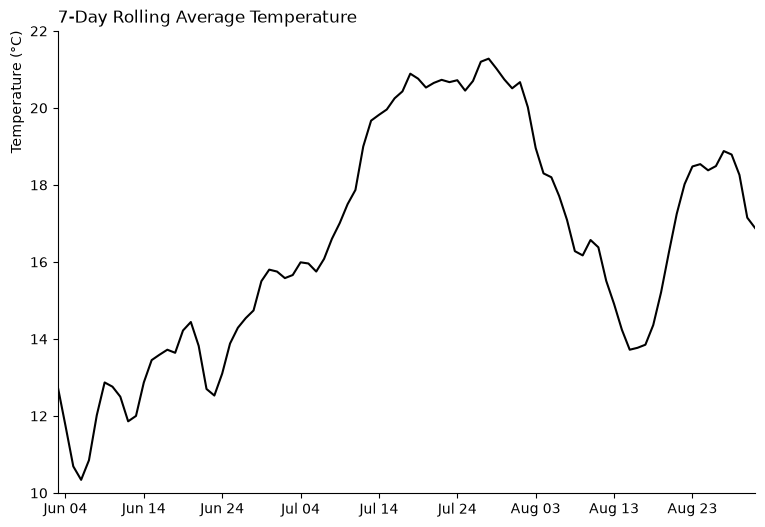

In [6]:
# Visualize

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(output_df.index, output_df["rolling_temperature"], color="k")

ax.set_xlim(output_df.index.min(), output_df.index.max())
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

ax.set_ylim(10, 22)
ax.set_ylabel("Temperature (°C)", loc="top")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_title("7-Day Rolling Average Temperature", loc="left")

fig.savefig("outputs/rolling_average_temperature.png", dpi=150, bbox_inches="tight")
plt.show()